# Weather Condition Classification — Data Preprocessing, Feature Selection, and Model Evaluation

This notebook implements the complete machine-learning workflow for classifying weather conditions from the supplied dataset.

The workflow covers:

1. Data loading and validation
2. Temporal feature engineering
3. Condition preprocessing
4. Lag-feature generation
5. Data cleaning and missing-value handling
6. Target encoding
7. Multi-method feature selection
8. Training and evaluation of multiple classification models

Each computational step is preceded by a Markdown explanation describing **what is being done, why it is required, and how it contributes to the overall analysis**.

## Imports and Library Setup

The required Python libraries are imported at the beginning of the notebook. These libraries provide functionality for data manipulation, visualization, preprocessing, feature selection, model training, and evaluation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dateutil import parser
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

## 1. Data Loading

The dataset is loaded from the Excel workbook and its initial structure is inspected. Before any preprocessing is performed, the required columns are checked to ensure that the dataset contains the variables needed for the subsequent feature-engineering and classification workflow.


In [19]:
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Projectdata.xlsx"

df = pd.read_excel(DATA_PATH)
print(f"Initial DataFrame shape: {df.shape}")

required_columns = ["Time", "DATE", "Condition"]
missing_required = [col for col in required_columns if col not in df.columns]
if missing_required:
    raise KeyError(f"Missing required columns: {missing_required}")

Initial DataFrame shape: (77341, 10)


## 2. Time Feature Engineering

The time field is converted into a consistent datetime representation and the hour of observation is extracted. This converts the original time information into a numerical feature that can be used by the machine-learning pipeline.


In [7]:
time_hms = pd.to_datetime(df["Time"].astype(str), format="%H:%M:%S", errors="coerce")
time_hm = pd.to_datetime(df["Time"].astype(str), format="%H:%M", errors="coerce")
df["Time"] = time_hms.fillna(time_hm)
df["hour"] = df["Time"].dt.hour

# Missing hour values are treated as 0 (midnight).
df["hour"] = df["hour"].fillna(0).astype(int)

## 3. Date and Day-of-Week Feature Engineering

The date values are parsed safely because Excel and string-based date values may appear in different formats. The resulting date information is then converted into a day-of-week representation, allowing temporal patterns to be incorporated into the feature set.


In [8]:
def safe_parse(value):
    """Safely parse Excel/string dates without crashing on invalid values."""
    if pd.isna(value):
        return pd.NaT

    if isinstance(value, (pd.Timestamp, np.datetime64)):
        return pd.to_datetime(value, errors="coerce")

    try:
        return parser.parse(str(value), fuzzy=True)
    except (ValueError, TypeError, OverflowError):
        return pd.NaT


df["date"] = df["DATE"].apply(safe_parse)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["Day"] = df["date"].dt.day_name()
weekday_map = {
    "Monday": 1,
    "Tuesday": 2,
    "Wednesday": 3,
    "Thursday": 4,
    "Friday": 5,
    "Saturday": 6,
    "Sunday": 7,
}
df["Day"] = df["Day"].map(weekday_map)
df["Day of Week"] = df["Day"]

print("Day of Week created successfully.")

Day of Week created successfully.


## 4. Condition Simplification

The target variable, `Condition`, is standardized by retaining the primary condition label and removing additional text after the first period. This creates a more consistent categorical target before label encoding.


In [9]:
df["Condition"] = (
    df["Condition"]
    .astype("string")
    .str.split(".")
    .str[0]
    .str.strip()
    .add(".")
)

print("Condition column simplified.")

Condition column simplified.


## 5. Sort Data Before Creating Lag Features

The observations are ordered chronologically before lag variables are generated. This is important because a lag feature represents a previous observation, so the temporal order of the records must be preserved.


In [10]:
# Lag values only make sense when rows are in chronological order.
df = df.sort_values(["date", "Time"], kind="stable").reset_index(drop=True)

## 6. Lag Feature Generation

Lagged weather variables are created to represent previous observations at selected time intervals. These historical values provide the models with temporal context that is not available from the current observation alone. Source weather variables are converted to numeric form and missing values are interpolated before lag construction.


In [11]:
def create_lag_features(df_in, lag_mapping):
    df_out = df_in.copy()

    for feature, lags in lag_mapping.items():
        if feature not in df_out.columns:
            print(f"Warning: '{feature}' not found; skipping lag creation.")
            continue

        # Make sure lagged weather variables are numeric.
        df_out[feature] = pd.to_numeric(df_out[feature], errors="coerce")

        for lag in lags:
            lag_feature_name = f"Lag_{lag}_{feature}"
            df_out[lag_feature_name] = df_out[feature].shift(lag)

    return df_out


feature_lag_mapping = {
    "Temperature(Â°C)": [1, 3, 6, 24],
    "Wind Speed(km/h)": [1, 3, 6],
    "Humidity": [24, 168],
    "Pressure(mbar)": [1, 24, 720],
    "Visibility": [1, 3],
}

# Convert source lag variables to numeric before interpolation.
features_for_interpolation = [
    feature for feature in feature_lag_mapping if feature in df.columns
]

for feature in features_for_interpolation:
    df[feature] = pd.to_numeric(df[feature], errors="coerce")

if features_for_interpolation:
    df[features_for_interpolation] = (
        df[features_for_interpolation]
        .interpolate(method="linear", limit_direction="both")
        .ffill()
        .bfill()
    )

df = create_lag_features(df, feature_lag_mapping)

max_lag = max(
    (lag for lags in feature_lag_mapping.values() for lag in lags),
    default=0,
)

if max_lag > 0 and len(df) > max_lag:
    df = df.iloc[max_lag:].reset_index(drop=True)

print(f"Maximum lag used: {max_lag}")

Maximum lag used: 720


## 7. Cyclical Time Features and Data Cleanup

The hour variable is transformed into sine and cosine components so that the model can represent the cyclical nature of time. Redundant date/time columns are then removed to produce a cleaner modeling dataset.


In [12]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)
df.drop(columns=["hour"], inplace=True)

columns_to_drop = ["Time", "date", "DATE", "Day", "Year", "Month"]
columns_to_drop = [col for col in columns_to_drop if col in df.columns]
if columns_to_drop:
    df.drop(columns=columns_to_drop, inplace=True)

print(f"Dropped redundant columns: {columns_to_drop}")
print(f"DataFrame shape after lag features and cleanup: {df.shape}")

Dropped redundant columns: ['Time', 'date', 'DATE', 'Day', 'Year', 'Month']
DataFrame shape after lag features and cleanup: (76621, 23)


## 8. Numeric Conversion and Missing-Value Handling

All predictor variables are converted to numeric values so they can be processed by the machine-learning algorithms. Missing values in source and lagged weather features are filled using forward and backward propagation where appropriate.


In [13]:
# All predictor columns need to be numeric for sklearn feature selection.
for col in df.columns:
    if col != "Condition":
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Handle NaNs in lagged/source weather features.
lagged_features_for_nan_fill = [
    col for col in df.columns
    if "Lag_" in col or col in feature_lag_mapping
]

for feature in lagged_features_for_nan_fill:
    if feature in df.columns:
        df[feature] = df[feature].ffill().bfill()

## 9. Pressure Cleaning and Scaling

Pressure-related variables are cleaned by treating zero values as missing observations and interpolating missing values. The valid pressure features are then normalized using min-max scaling so that their numerical range is comparable across observations.


In [14]:
pressure_columns = [
    "Lag_1_Pressure(mbar)",
    "Lag_24_Pressure(mbar)",
    "Lag_720_Pressure(mbar)",
    "Pressure(mbar)",
]

for col in pressure_columns:
    if col not in df.columns:
        continue

    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].interpolate(method="linear", limit_direction="both")
    df[col] = df[col].bfill().ffill()

    # Avoid divide-by-zero if the column is constant.
    col_min = df[col].min()
    col_max = df[col].max()
    if pd.notna(col_min) and pd.notna(col_max) and col_max != col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    elif pd.notna(col_min):
        df[col] = 0.0

print("Pressure columns handled and scaled.")


# Final numeric NaN handling.
numeric_columns = df.select_dtypes(include=np.number).columns
for col in numeric_columns:
    if df[col].isnull().any():
        mean_value = df[col].mean()
        df[col] = df[col].fillna(0 if pd.isna(mean_value) else mean_value)

Pressure columns handled and scaled.


## 10. Label Encoding for the Target Variable

The categorical `Condition` target is converted into numerical class labels using `LabelEncoder`. Missing target values are assigned an `Unknown.` category before encoding, and the resulting class mapping is displayed for transparency.


In [15]:
if df["Condition"].isnull().any():
    df["Condition"] = df["Condition"].fillna("Unknown.")

df["Condition"] = df["Condition"].astype(str)
label_encoder = LabelEncoder()
df["Condition"] = label_encoder.fit_transform(df["Condition"])

print("Condition column label encoded.")
print("Classes:", list(label_encoder.classes_))

Condition column label encoded.
Classes: ['0.', 'Broken clouds.', 'Clear.', 'Cool.', 'Dense fog.', 'Drizzle.', 'Duststorm.', 'Extremely hot.', 'Fog.', 'Hail.', 'Haze.', 'Hot.', 'Light fog.', 'Light rain.', 'Mild.', 'More clouds than sun.', 'Mostly cloudy.', 'Overcast.', 'Partly cloudy.', 'Partly sunny.', 'Passing clouds.', 'Pleasantly warm.', 'Quite cool.', 'Rain showers.', 'Rain.', 'Refreshingly cool.', 'Sandstorm.', 'Scattered clouds.', 'Smoke.', 'Strong thunderstorms.', 'Sunny.', 'Thundershowers.', 'Thunderstorms.', 'Warm.']


## 11. Feature Selection

Multiple feature-selection techniques are applied to identify informative predictors: variance thresholding, correlation analysis, mutual information, and Lasso-based selection. Features common to these approaches are retained where possible, with a fallback strategy used if their intersection is empty.


Variance threshold selected features count: 20
Correlation selected features count: 16


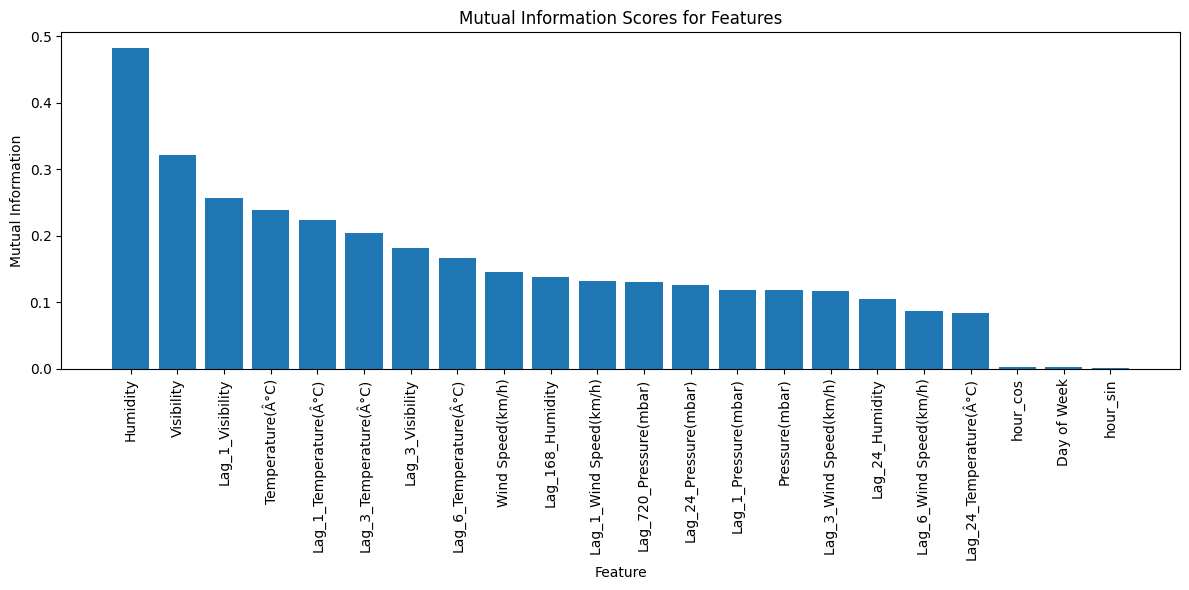

Mutual Information selected features count: 19
Lasso selected features count: 19
Selected features (15): ['Lag_1_Temperature(Â°C)', 'Lag_1_Visibility', 'Lag_1_Wind Speed(km/h)', 'Lag_24_Pressure(mbar)', 'Lag_24_Temperature(Â°C)', 'Lag_3_Temperature(Â°C)', 'Lag_3_Visibility', 'Lag_3_Wind Speed(km/h)', 'Lag_6_Temperature(Â°C)', 'Lag_6_Wind Speed(km/h)', 'Lag_720_Pressure(mbar)', 'Pressure(mbar)', 'Temperature(Â°C)', 'Visibility', 'Wind Speed(km/h)']


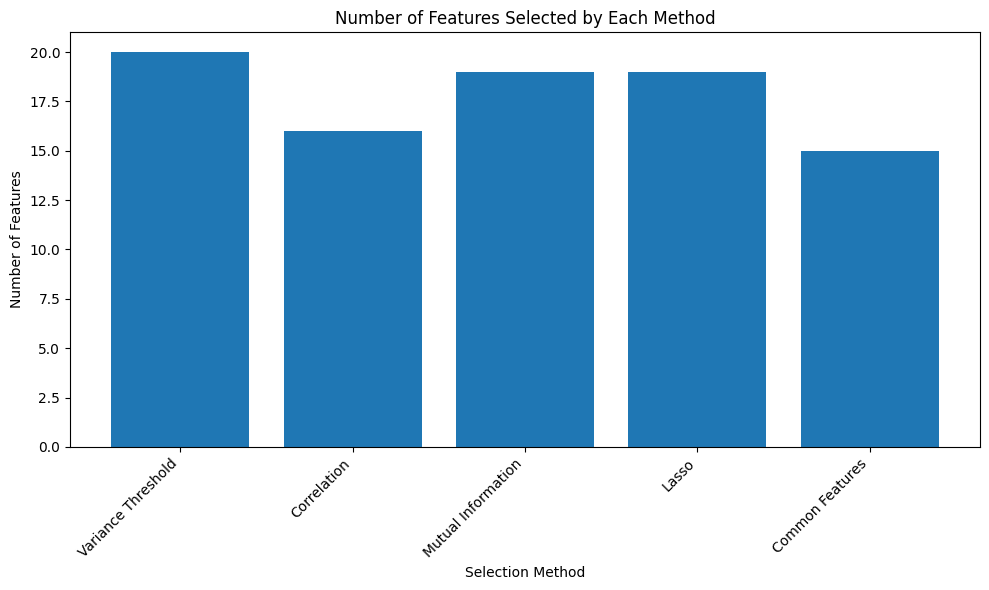

In [16]:
bf = df.copy()
X_all = df.drop(columns=["Condition"])
y_all = df["Condition"]

# Keep only numeric predictors.
X_all = X_all.select_dtypes(include=np.number)

if X_all.empty:
    raise ValueError("No numeric predictor columns are available for feature selection.")

# ---------- Variance Threshold ----------
selector = VarianceThreshold(threshold=0.01)

try:
    selector.fit(X_all)
    selected_features_V = X_all.columns[selector.get_support()]
except ValueError:
    # All columns have very low/zero variance.
    selected_features_V = pd.Index(X_all.columns)

print(f"Variance threshold selected features count: {len(selected_features_V)}")

# ---------- Correlation ----------
correlation_matrix = bf.select_dtypes(include=np.number).corr()

if "Condition" in correlation_matrix.columns:
    condition_correlation = correlation_matrix["Condition"].drop(labels=["Condition"], errors="ignore")
    highly_correlated_features = condition_correlation[
        (condition_correlation > 0.10) | (condition_correlation < -0.10)
    ].index.tolist()
else:
    highly_correlated_features = []

print(f"Correlation selected features count: {len(highly_correlated_features)}")

# ---------- Mutual Information ----------
if not X_all.empty and not y_all.empty:
    mi_scores = mutual_info_classif(
        X_all,
        y_all,
        discrete_features="auto",
        random_state=42,
    )

    mi_scores_df = pd.DataFrame({
        "Feature": X_all.columns,
        "Mutual Information": mi_scores,
    }).sort_values(by="Mutual Information", ascending=False)

    threshold_mi = 0.01
    selected_features_MF = mi_scores_df.loc[
        mi_scores_df["Mutual Information"] > threshold_mi,
        "Feature",
    ].tolist()

    # Visualize Mutual Information scores
    plt.figure(figsize=(12, 6))
    plt.bar(mi_scores_df["Feature"], mi_scores_df["Mutual Information"])
    plt.xticks(rotation=90)
    plt.title("Mutual Information Scores for Features")
    plt.xlabel("Feature")
    plt.ylabel("Mutual Information")
    plt.tight_layout()
    plt.show()
else:
    selected_features_MF = []

print(f"Mutual Information selected features count: {len(selected_features_MF)}")

# ---------- Lasso ----------
# Lasso is retained to match the original methodology.
# Standardization is required because Lasso is scale-sensitive.
if not X_all.empty and not y_all.empty:
    scaler_lasso = StandardScaler()
    X_scaled_lasso = scaler_lasso.fit_transform(X_all)

    lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
    lasso.fit(X_scaled_lasso, y_all)

    selected_features_L = X_all.columns[np.abs(lasso.coef_) > 1e-8]
else:
    selected_features_L = pd.Index([])

print(f"Lasso selected features count: {len(selected_features_L)}")

# ---------- Common Features ----------
mutual_info_set = set(selected_features_MF)
lasso_selected_set = set(selected_features_L)
correlated_set = set(highly_correlated_features)
variance_set = set(selected_features_V)

common_features = mutual_info_set.intersection(
    lasso_selected_set,
    correlated_set,
    variance_set,
)

# A completely empty intersection would make every model fail.
# Fall back to the strongest available feature-selection set.
if not common_features:
    fallback_features = (
        mutual_info_set
        .intersection(variance_set)
        or lasso_selected_set.intersection(variance_set)
        or correlated_set.intersection(variance_set)
    )

    if fallback_features:
        common_features = fallback_features
    else:
        common_features = set(variance_set) or set(X_all.columns)

features = sorted(common_features)
print(f"Selected features ({len(features)}): {features}")

# Visualize the number of features selected by each method
selection_counts = {
    "Variance Threshold": len(selected_features_V),
    "Correlation": len(highly_correlated_features),
    "Mutual Information": len(selected_features_MF),
    "Lasso": len(selected_features_L),
    "Common Features": len(features)
}

plt.figure(figsize=(10, 6))
plt.bar(selection_counts.keys(), selection_counts.values())
plt.title("Number of Features Selected by Each Method")
plt.xlabel("Selection Method")
plt.ylabel("Number of Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 12. Model Training and Evaluation

The selected features are divided into training and testing sets. Multiple classification algorithms are then trained and evaluated using test-set accuracy. Where the class distribution permits, stratified sampling is used to preserve class proportions. Finally, the model accuracies are visualized for comparison.


Stratified split disabled because at least one class has fewer than 2 samples. Minimum class count: 1
Rare classes:
Condition
25    1
26    1
9     1
X_train shape: (61296, 15)
X_test shape: (15325, 15)
Logistic Regression Accuracy: 0.4882
Random Forest Accuracy: 0.7209
SVM Accuracy: 0.5836
KNN Accuracy: 0.6155
Neural Network Accuracy: 0.5955
XGBoost Accuracy: 0.6956


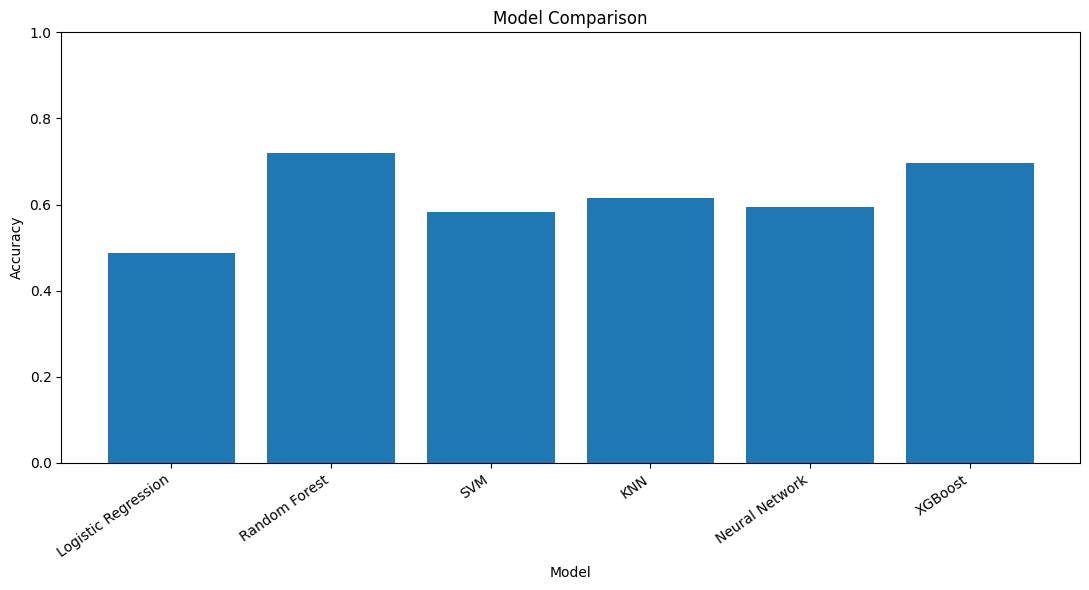

In [17]:
if not df.empty and features:
    X = df[features]
    y = df["Condition"]

    # Check class distribution before using stratification
    class_counts = y.value_counts()
    min_class_count = class_counts.min()
    n_classes = y.nunique()

    # Number of samples that will go into the test set
    test_samples = int(np.ceil(len(y) * 0.20))

    # Stratification is possible only when:
    # 1. Every class has at least 2 samples
    # 2. Test set is large enough to contain every class
    if min_class_count >= 2 and test_samples >= n_classes:
        stratify_value = y
        print("Stratified train/test split enabled.")
    else:
        stratify_value = None

        print(
            "Stratified split disabled because at least one class "
            f"has fewer than 2 samples. Minimum class count: {min_class_count}"
        )

        rare_classes = class_counts[class_counts < 2]

        if not rare_classes.empty:
            print("Rare classes:")
            print(rare_classes.to_string())

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=stratify_value
    )

    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")

    models = {
        "Logistic Regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, random_state=42),
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        ),
        "SVM": make_pipeline(
            StandardScaler(),
            SVC(),
        ),
        "KNN": make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=5),
        ),
        "Neural Network": make_pipeline(
            StandardScaler(),
            MLPClassifier(random_state=42, max_iter=1000),
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            random_state=42,
            eval_metric="mlogloss",
            n_jobs=-1,
        ),
    }

    model_accuracies = {}

    for name, model in models.items():
        try:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            model_accuracies[name] = accuracy
            print(f"{name} Accuracy: {accuracy:.4f}")
        except Exception as exc:
            print(f"{name} failed: {exc}")

    # ---------- Model Comparison ----------
    if model_accuracies:
        plt.figure(figsize=(11, 6))
        plt.bar(
            list(model_accuracies.keys()),
            list(model_accuracies.values()),
        )
        plt.ylabel("Accuracy")
        plt.xlabel("Model")
        plt.title("Model Comparison")
        plt.ylim(0, 1)
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print("No model completed successfully.")
else:
    print("DataFrame is empty or no features were selected. Cannot proceed with model training.")